# Visualize Processed Data
This notebook loads `03-PROCESSED-DATA/data_processed.csv` and creates a few quick plots for inspection.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
csv_path = Path('03-PROCESSED-DATA/data_processed.csv')
df = pd.read_csv(csv_path, parse_dates=['timestamp'])
df = df.sort_values('timestamp')

print(f'Rows: {len(df):,}')
print('Columns:', list(df.columns))
df.head()

Rows: 35,137
Columns: ['timestamp', 'trafo1_kW', 'trafo2_kW', 'grid_exchange_kW', 'PV_kW', 'lkw_kW', 'zustellung_kW']


,timestamp,trafo1_kW,trafo2_kW,grid_exchange_kW,PV_kW,lkw_kW,zustellung_kW
0,2024-01-01 00:00:00,24.932023,0.040559,24.972582,0.048452,360.0,110.0
1,2024-01-01 00:15:00,77.346414,0.126048,77.472462,0.143257,720.0,110.0
2,2024-01-01 00:30:00,85.497055,0.128006,85.625061,0.141041,360.0,110.0
3,2024-01-01 00:45:00,80.501872,0.130178,80.632051,0.141019,360.0,110.0
4,2024-01-01 01:00:00,73.951393,0.128916,74.080309,0.141812,0.0,110.0


In [3]:
plot_df = df.set_index('timestamp').copy()
numeric_columns = plot_df.select_dtypes(include='number').columns.tolist()
numeric_columns

['trafo1_kW',
 'trafo2_kW',
 'grid_exchange_kW',
 'PV_kW',
 'lkw_kW',
 'zustellung_kW']

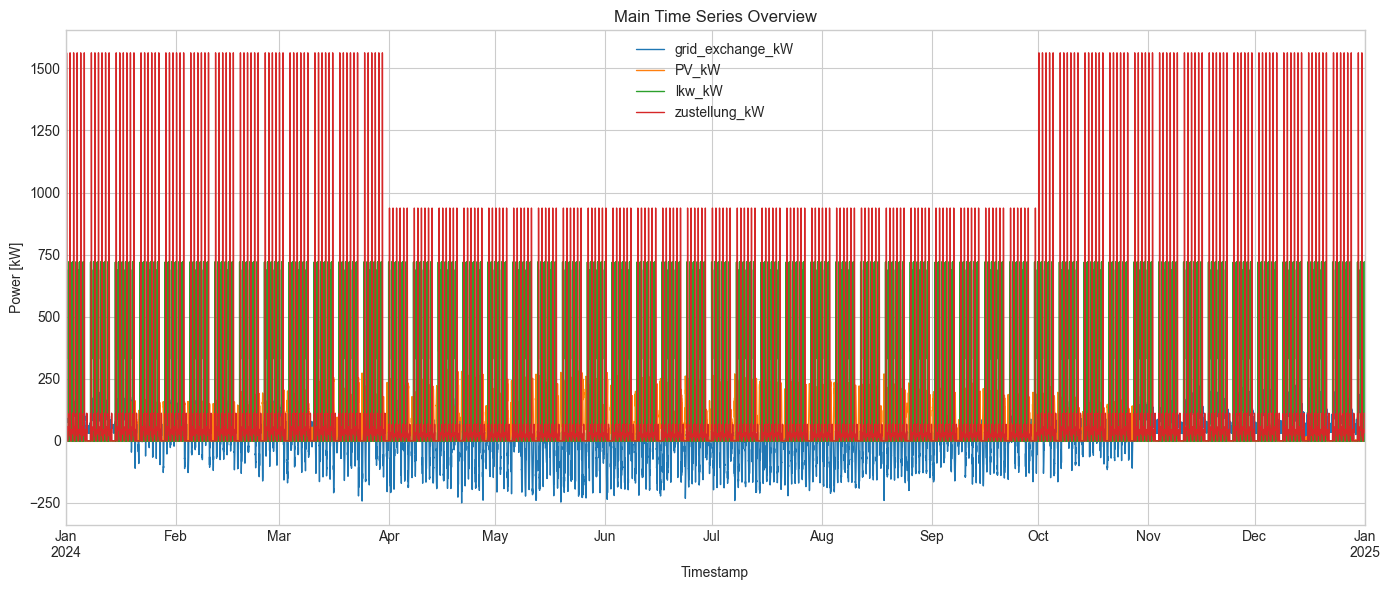

In [4]:
overview_columns = [
    column for column in ['grid_exchange_kW', 'PV_kW', 'lkw_kW', 'zustellung_kW']
    if column in plot_df.columns
]

ax = plot_df[overview_columns].plot(figsize=(14, 6), linewidth=1)
ax.set_title('Main Time Series Overview')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Power [kW]')
plt.tight_layout()
plt.show()

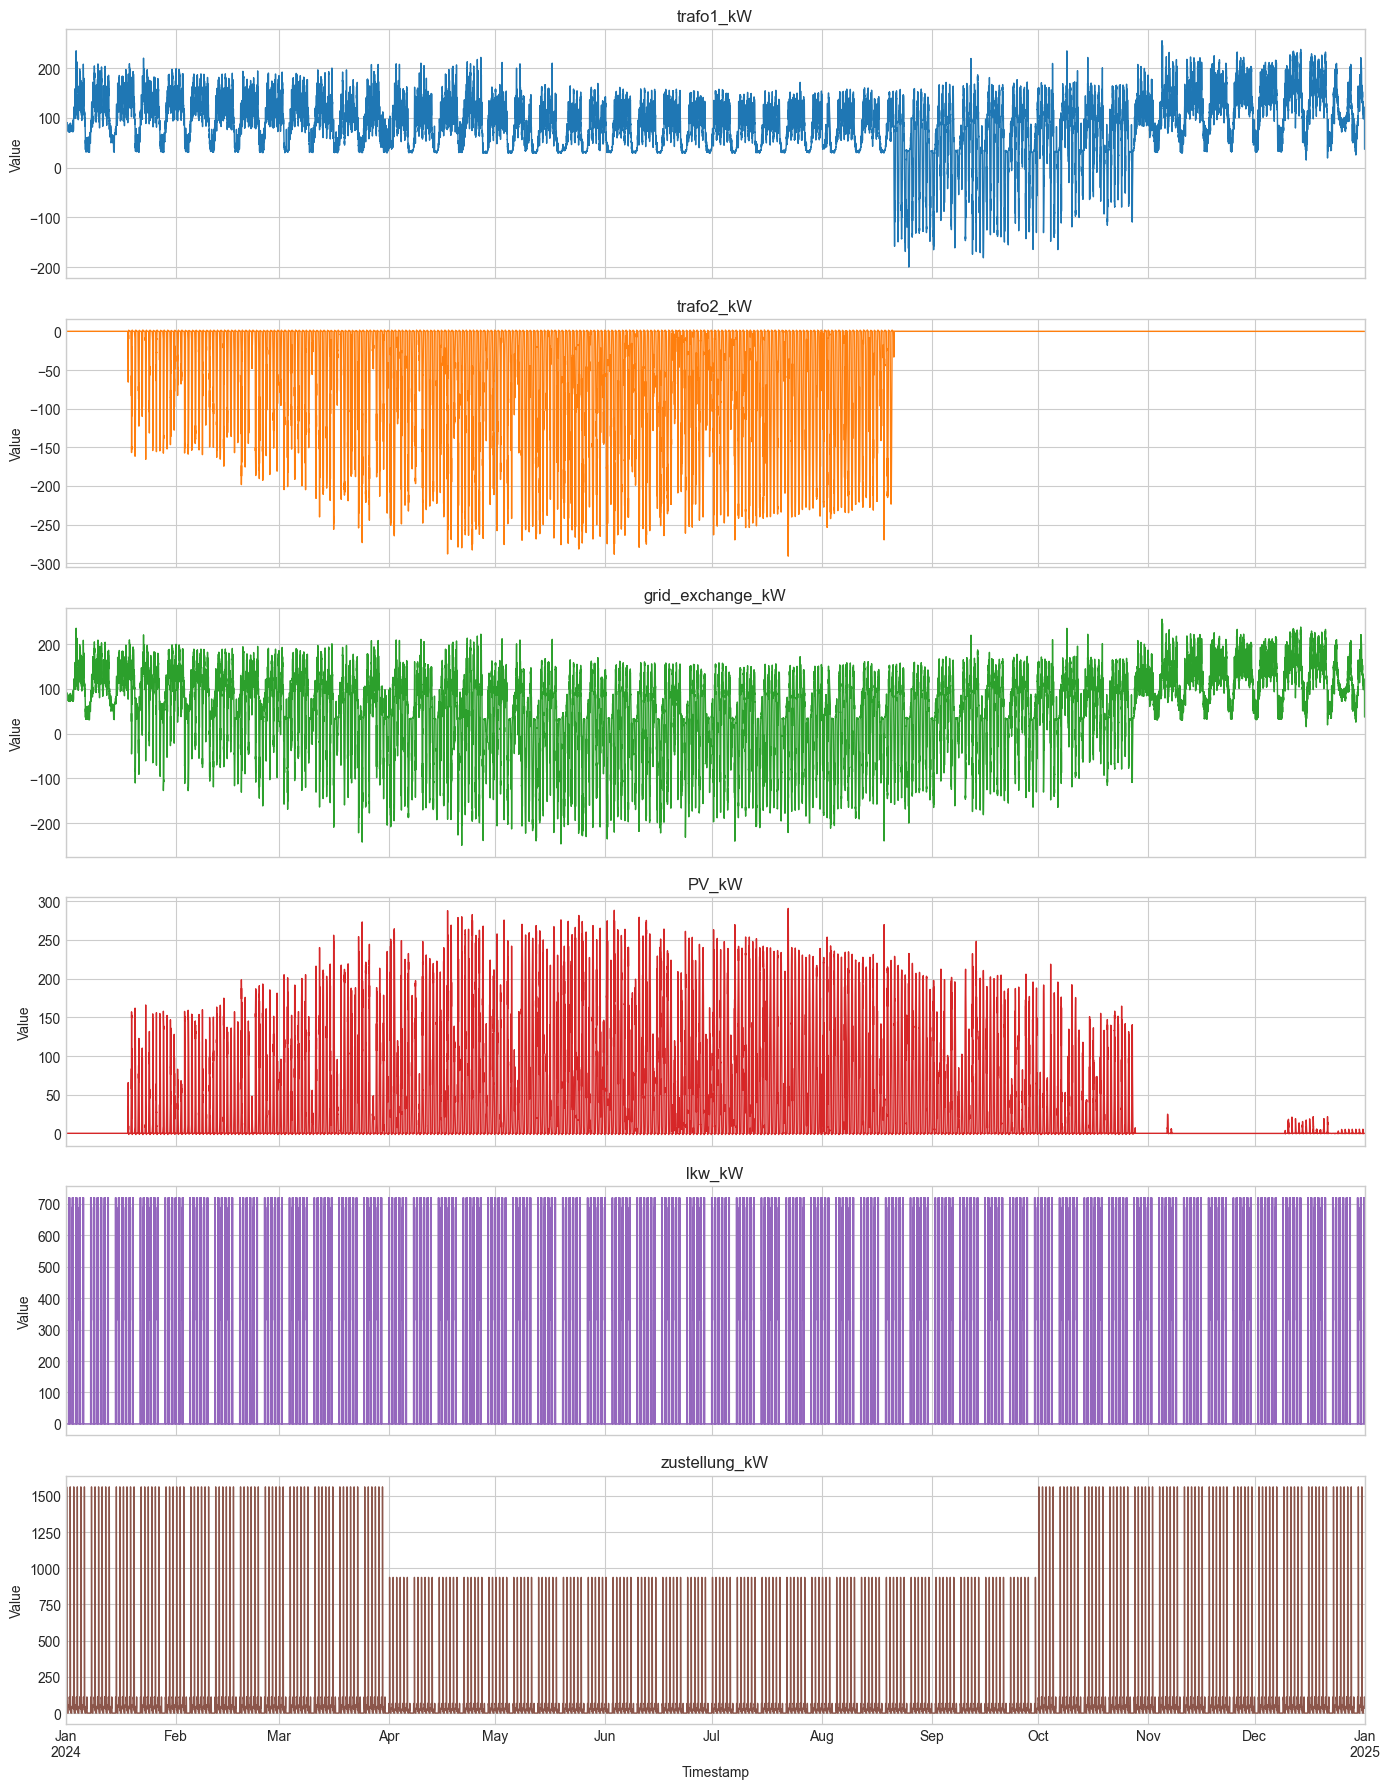

In [5]:
axes = plot_df[numeric_columns].plot(
    subplots=True,
    figsize=(14, max(8, 3 * len(numeric_columns))),
    linewidth=1,
    legend=False
)

for axis, column in zip(axes, numeric_columns):
    axis.set_title(column)
    axis.set_xlabel('Timestamp')
    axis.set_ylabel('Value')

plt.tight_layout()
plt.show()

In [6]:
plot_df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
trafo1_kW,35137.0,88.781551,57.705259,-199.678442,50.080782,94.124864,127.543404,255.443334
trafo2_kW,35137.0,-32.052169,64.209439,-290.932177,-22.102000,0.118851,0.145202,1.880571
grid_exchange_kW,35137.0,56.729382,92.174733,-249.540678,17.063023,76.387832,125.308738,255.551367
PV_kW,35137.0,39.799290,67.562784,-1.554336,0.126682,0.137664,56.683630,290.790459
lkw_kW,35136.0,101.328142,221.031671,0.000000,0.000000,0.000000,0.000000,720.000000
zustellung_kW,35136.0,85.599135,253.350079,0.000000,0.000000,25.800000,61.000000,1562.500000
